In [12]:
import numpy as np
import matplotlib.pyplot as plt


In [13]:
# Set a seed for reproducibility
np.random.seed(42)

# --- 1. Data Generation and Preprocessing ---
# Create a feature (X) and a target (y)
X = 2 * np.random.rand(100, 1)
# y: The true relationship is y = 4 + 3*X + noise
y = 4 + 3 * X + np.random.randn(100, 1)

print("--- Data Generation ---")
print(f"Generated {len(X)} samples.")

# To account for the intercept (bias) term, we must add a column of ones to X.
X_b = np.c_[np.ones((len(X), 1)), X] 
m = len(X) # Number of training examples

--- Data Generation ---
Generated 100 samples.


In [14]:
# --- 2. Model Training using Gradient Descent ---

# 2a. Hyperparameters
learning_rate = 0.01 # The step size for updates
n_iterations = 1000  # How many steps to take

# 2b. Initialization
# Initialize theta (coefficients: [intercept, slope]) randomly
theta = np.random.randn(2, 1) 
cost_history = [] # To track the MSE at each step

print(f"\n--- Model Training (Gradient Descent) ---")
print(f"Starting theta (randomly initialized):\n{theta.T}")

# 2c. Gradient Descent Loop
for iteration in range(n_iterations):
    # Calculate predictions (h_theta = X_b * theta)
    predictions = X_b.dot(theta)

    # Calculate the error term (predictions - y)
    error = predictions - y

    # Calculate the gradient of the Cost Function (J(theta))
    # Formula: Gradient = (2/m) * X_T * error
    gradients = 2/m * X_b.T.dot(error)

    # Update theta: theta = theta - (learning_rate * gradients)
    theta = theta - learning_rate * gradients
    
    # Track the Mean Squared Error (Cost) for plotting
    mse = np.mean(error**2)
    cost_history.append(mse)

# Extract the final parameters
intercept = theta[0][0]
slope = theta[1][0]

print(f"**Iterations Completed:** {n_iterations}")
print(f"**Final Calculated Intercept (Bias):** {intercept:.4f}")
print(f"**Final Calculated Slope (Weight):** {slope:.4f}")
print(f"The learned line equation is: y = {slope:.4f} * X + {intercept:.4f}")



--- Model Training (Gradient Descent) ---
Starting theta (randomly initialized):
[[0.01300189 1.45353408]]
**Iterations Completed:** 1000
**Final Calculated Intercept (Bias):** 4.1581
**Final Calculated Slope (Weight):** 2.8204
The learned line equation is: y = 2.8204 * X + 4.1581


In [15]:
# --- 3. Prediction ---
# Create X_new for prediction (e.g., a line from 0 to 2)
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new] # Add the bias term (ones)
y_pred = X_new_b.dot(theta)

# Predict all existing values for evaluation
y_actual_pred = X_b.dot(theta)

In [16]:
# --- 4. Manual Evaluation Metrics ---

# 4a. Mean Squared Error (MSE)
def calculate_mse(y_actual, y_predicted):
    """Calculates Mean Squared Error."""
    errors = y_actual - y_predicted
    mse = np.mean(errors**2)
    return mse

# 4b. R-squared Score (Coefficient of Determination)
def calculate_r2(y_actual, y_predicted):
    """Calculates R-squared (R2) score."""
    y_mean = np.mean(y_actual)
    total_sum_of_squares = np.sum((y_actual - y_mean)**2)
    residual_sum_of_squares = np.sum((y_actual - y_predicted)**2)
    r2 = 1 - (residual_sum_of_squares / total_sum_of_squares)
    return r2

mse = calculate_mse(y, y_actual_pred)
rmse = np.sqrt(mse)
r2 = calculate_r2(y, y_actual_pred)

print("\n--- Manual Model Evaluation (on Full Dataset) ---")
print(f"**Mean Squared Error (MSE):** {mse:.4f}")
print(f"**Root Mean Squared Error (RMSE):** {rmse:.4f}")
print(f"**R-squared Score (R²):** {r2:.4f}")


--- Manual Model Evaluation (on Full Dataset) ---
**Mean Squared Error (MSE):** 0.8076
**Root Mean Squared Error (RMSE):** 0.8986
**R-squared Score (R²):** 0.7690


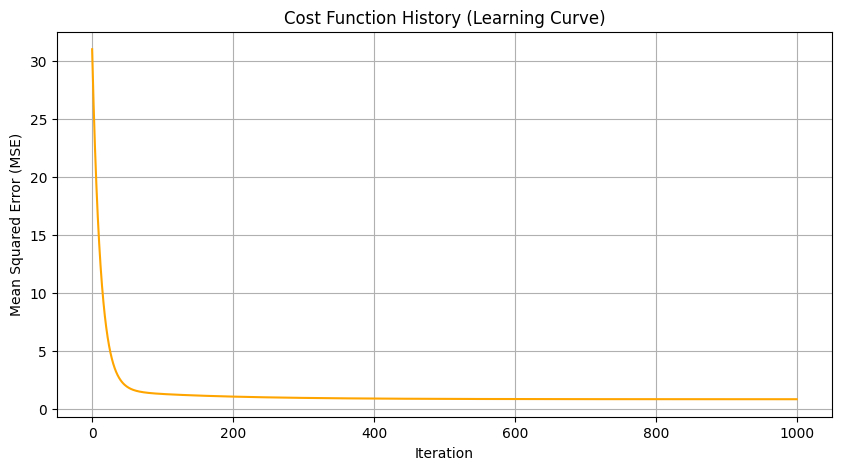

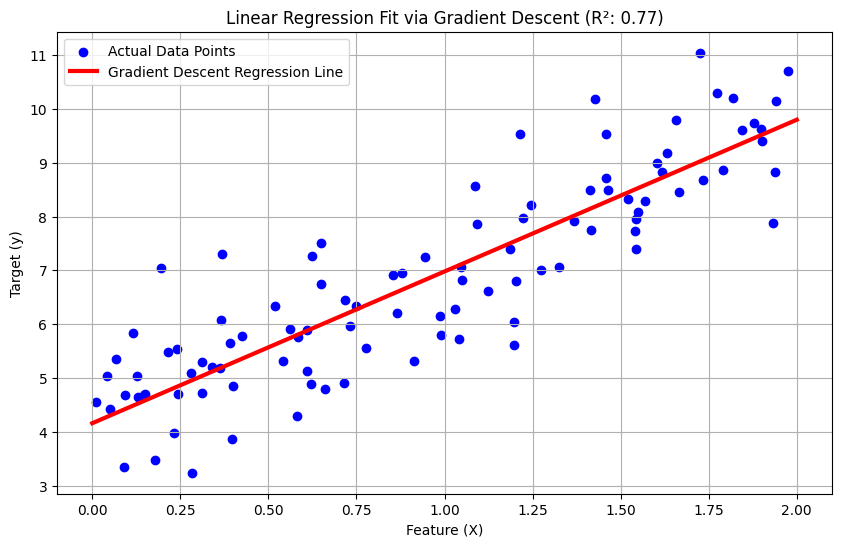

In [17]:
# --- 5. Visualization ---

# 5a. Plot Learning Curve (Cost History)
plt.figure(figsize=(10, 5))
plt.plot(range(n_iterations), cost_history, color='orange')
plt.title('Cost Function History (Learning Curve)')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.show()

# 5b. Plot Regression Line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data Points')
plt.plot(X_new, y_pred, color='red', linewidth=3, label='Gradient Descent Regression Line')

plt.title(f'Linear Regression Fit via Gradient Descent (R²: {r2:.2f})')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.legend()
plt.grid(True)
plt.show()